# Assignment: Exploratory Data Analysis

**Q1.** In class, we talked about how to compute the sample mean of a variable $X$,
$$
m(X) = \dfrac{1}{N} \sum_{i=1}^N x_i
$$
and sample covariance of two variables $X$ and $Y$,
$$
\text{cov}(X,Y) = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))(y_i - m(Y))).
$$
Recall, the sample variance of $X$ is
$$
s^2 = \dfrac{1}{N} \sum_{i=1}^N (x_i - m(X))^2.
$$
It can be very helpful to understand some basic properties of these statistics. If you want to write your calculations on a piece of paper, take a photo, and upload that to your GitHub repo, that's probably easiest.

1. Show that $m(a + bX) = a+b \times m(X)$.
2. Show that $\text{cov}(X,a+bY) = b \times \text{cov}(X,Y)$
3. Show that $\text{cov}(a+bX,a+bX) = b^2 \text{cov}(X,X) $, and in particular that $\text{cov}(X,X) = s^2 $.
4. Consider a non-decreasing transformation $g()$. Is is always true that $m(g(X))= g(m(X))$?

**Q2.** This question looks at financial transfers from foreign entities to American universities. In particular, from which countries and giftors are the gifts coming from, and to which institutions are they going? For this question, `.groupby([vars]).count()` and `.groupby([vars]).sum()` will be especially useful to tally the number of occurrences and sum the values of those occurrences.

1. Load the `./data/ForeignGifts_edu.csv` dataset.
2. For `Foreign Gift Amount`, create a histogram and describe the variable. Describe your findings.
3. For `Gift Type`, create a histogram or value counts table. What proportion of the gifts are contracts, real estate, and monetary gifts?
4. Create a kernel density plot of the log of `Foreign Gift Amount`, and then a kernel density plot of the log of `Foreign Gift Amount` conditional on gift type. Do you notice any patterns?
5. What are the top 15 countries in terms of the number of gifts? What are the top 15 countries in terms of the amount given?
6. Which giftors provide the most money, in total?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Claire Curzan

**Date:** 9/9/2026

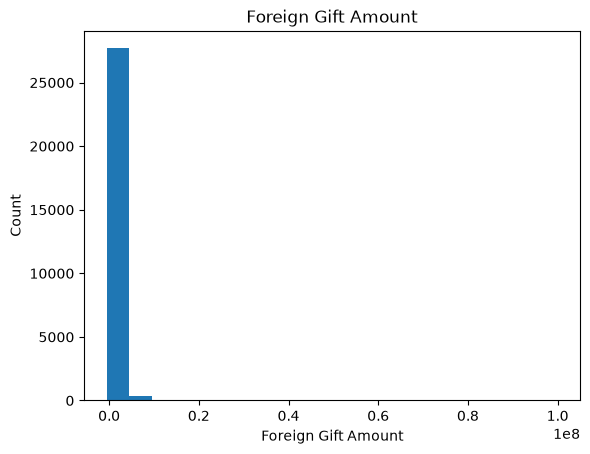

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


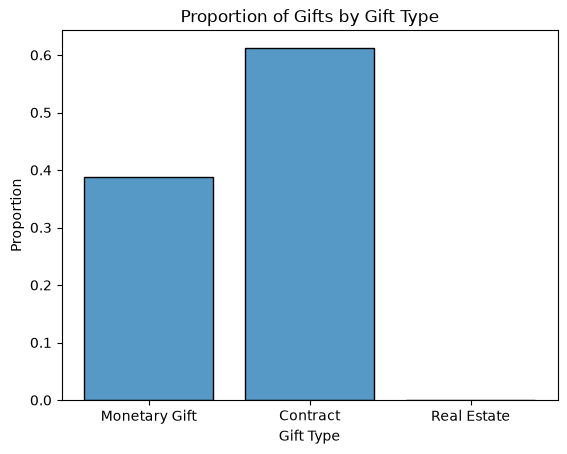

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64


/workspaces/A02-eda-and-visualization/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


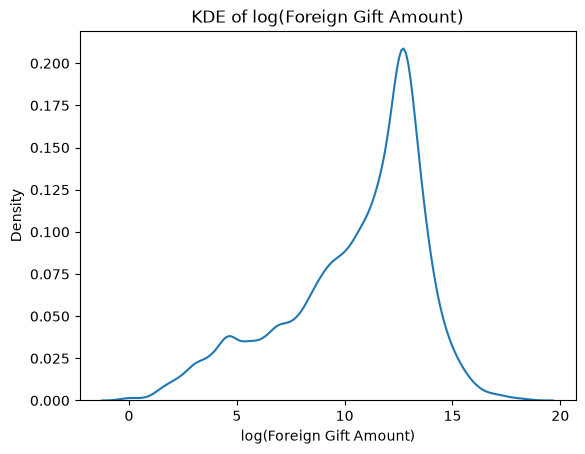

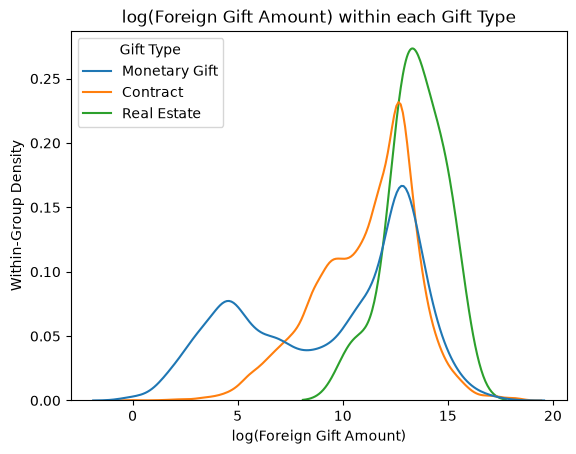

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [12]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.
gifts_df = pd.read_csv("./data/ForeignGifts_edu.csv")

# 2.
gifts_df["Foreign Gift Amount"].hist(bins = 20, grid = False)
plt.title("Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.show()

print(gifts_df["Foreign Gift Amount"].describe())

# Findings: The mean gift amount is about $588,233, but the median is only $94,615 (this means the mean is roughly 6x
# the median). This is a strong indicator to me that there is a right skew. The middle 50% of gifts fall between $5,700 
# and $376,142, while the max single gift is $99,999,999. A plain histogram on the raw scale is essentially useless because
# almost every bar will pile up near the left of the graph (nearish to zero) because that one outlier stretches the x-axis.

# 3.
sns.histplot(data=gifts_df, x = "Gift Type", stat = "proportion", discrete = True, shrink = 0.8)
plt.title("Proportion of Gifts by Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Proportion")
plt.show()

print(gifts_df["Gift Type"].value_counts(normalize = True))

# Findings: Contract 61.2%, Monetary Gift 38.8%, Real Estate 0.04%

# 4.
gifts_df["log_gift_amount"] = np.log(gifts_df["Foreign Gift Amount"])

sns.kdeplot(x = gifts_df["log_gift_amount"])
plt.title("KDE of log(Foreign Gift Amount)")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

sns.kdeplot(data = gifts_df, x = "log_gift_amount", hue = "Gift Type", common_norm = False)
plt.title("log(Foreign Gift Amount) within each Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Within-Group Density")
plt.show()

# Findings: The log-transformed KDE plot shows that gift type is closely related with gift size. Once the right skew is pulled
# in by the log transformation, the overall distribution looks roughly bell-shaped, unlike the skewed raw scale. Conditioning
# by type, Real Estate gifts sit furthest to the right, meaning they tend to be the largest gifts. Contract gifts cluster in a 
# harrower, higher peak, which could mean most of those Contracts fall within a fairly consistant, moderate dollar range.
# Monetary Gifts on the other hand show a much flatter, wider spread, reflecting that this category includes everything from very
# small donations to very large gifts rather than clustering around one typical size. Overall, I think that these patters suggest
# that while contracts are the most common gift type, monetary gifts vary the most in size, and real estate tends to involve the 
# largest amounts. 

# 5.
top15_count = gifts_df.groupby("Country of Giftor")["Foreign Gift Amount"].count().sort_values(ascending = False).head(15)
print(top15_count)

# Top 15 Countries (# gifts): ENGLAND, CHINA, CANADA, JAPAN, SWITZERLAND, SAUDI ARABIA, FRANCE, GERMANY, HONG KONG, SOUTH KOREA, QATAR, THE NETHERLANDS,
# KOREA, INDIA, TAIWAN

top15_amount = gifts_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending = False).head(15)
print(top15_amount)

# Top 15 Countries (amt given): QATAR, ENGLAND, CHINA, SAUDI ARABIA, BERMUDA, CANADA, HONG KONG, JAPAN, SWITZERLAND, INDIA, GERMANY, UNITED ARAB EMIRATES,
# FRANCE, SINGAPORE, AUSTRALIA

# 6.
top_giftors = gifts_df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending = False).head(15)
print(top_giftors)

# Top Giftor: Qatar Foundation, Qatar Foundation/Qatar National Res, Qatar Foundation for Education, Anonymous, Saudi Arabian Cultural Mission, HCL,
# Church of Jesus Christ of LDS, Emirates Institute for Advanced Sc, QIC, Anonymous #9, Qatar National Research Fund, Government of Saudi Arabia, Contracting Party,
# CMKL University, Royal Embassy of Saudi Arabia


## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 18fe7bf (for the code for Phase 1) and 74ffb5c (for the pictures for Q1 Phase 1)
- **AI tool and model used:** Claude Sonnet 5

### *Prompts used

1. Can you please review my code for this homework and make suggestions to improve it?
2. Can you double-check the groupby logic I used for counting gifts by country, and check whether the log transform in Q4 could run into any issues with the data?

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. .count() undercounts if there are missing values. For the "top 15 countries by number of gifts" groupby, you used .count() on Foreign Gift Amount, which skips rows where that column is NaN. If any gifts are missing an amount but still represent a real gift, your count will be off. .groupby("Country of Giftor").size() counts rows regardless of missingness, which is what "number of gifts" actually means.

2. No missing-value check before starting. Running gifts_df.isna().sum() early (right after loading) would tell you whether Foreign Gift Amount, Country of Giftor, or Giftor Name have any nulls — which matters for #1 above and for whether your counts/sums are complete.

3. np.log() on zero or negative values silently produces -inf/NaN/warnings. Before your log transform in Q4, check gifts_df["Foreign Gift Amount"].min(). If there are any $0 gifts, np.log(0) is -inf, which can quietly distort your KDE plot's x-axis or get dropped by seaborn without you noticing. Worth confirming the min value and deciding explicitly (e.g., filter zeros, or note there are none).

4. Dollar figures are hard to read as raw floats. When you print top15_amount and top_giftors, the values will show as long unformatted floats (e.g., 588233000.0). Formatting with .map('${:,.0f}'.format) or similar makes the printed table actually readable — doesn't change any values.

5. Gift Type histogram has no explicit category order. sns.histplot(..., discrete=True) will order bars however pandas orders the categories internally, not by frequency or a logical order. Passing an explicit order=[...] (or sorting first) makes the chart easier to read at a glance.

6. Manually retyped numbers in your comments can drift from the code. You wrote out means/medians/percentages by hand in comments (e.g., "$588,233", "61.2%"). Referencing the computed values directly with an f-string (e.g., print(f"Mean: {gifts_df['Foreign Gift Amount'].mean():,.0f}")) ties your write-up to the actual output, so if the data or code changes, your narrative can't silently go stale.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1. .count() changed to .size() | Accept | .size() is  a more robust choice going forward so my code doesn't drop rows where Foreign Gift Amount is NaN, so I'll accept. |
| 2. Add explicit missing-value check at the top | Reject | Redundant with the verification I already ran for #1. |
| 3. Check for zero\negative values before np.log() | Accpet | Easy check to add to confirm that my plot for Q4 is reliable. |
| 4. Format dollar figures with commas when printing | Reject | Purely cosmetic so unnecessary to me. |
| 5. Add explicit category order to Gift Type histogram | Reject | Cosmetic readability tweak only so unnecessary to me. |
| 6. Report only the single top giftor instead of top 15 | Reject | I may have misinterpreted the question but I don't mind listing out 15 even if the question asks for 1. Hopefully that's not incorrect! |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

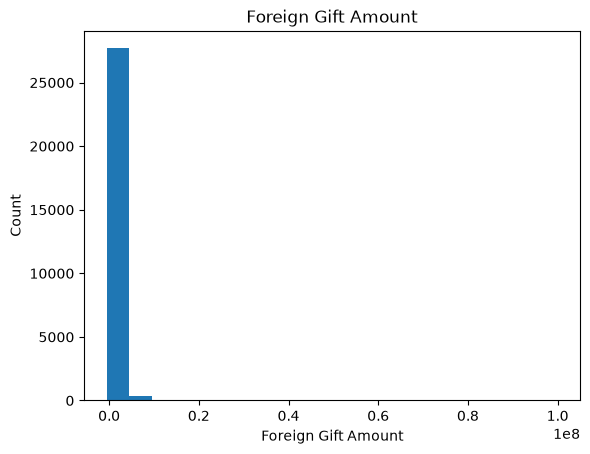

count    2.822100e+04
mean     5.882327e+05
std      3.222011e+06
min     -5.377700e+05
25%      5.700000e+03
50%      9.461500e+04
75%      3.761420e+05
max      1.000000e+08
Name: Foreign Gift Amount, dtype: float64


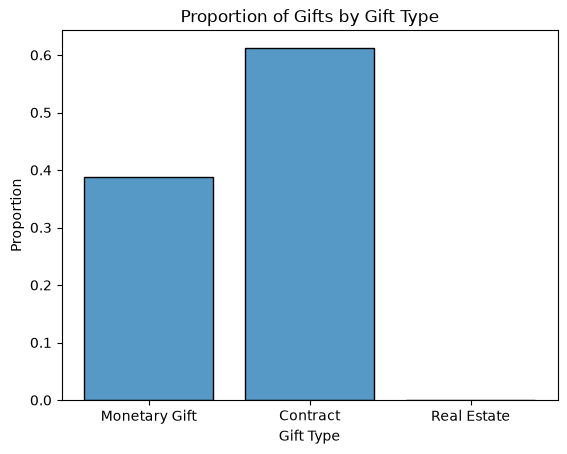

Gift Type
Contract         0.612097
Monetary Gift    0.387513
Real Estate      0.000390
Name: proportion, dtype: float64
-537770


/workspaces/A02-eda-and-visualization/.venv/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


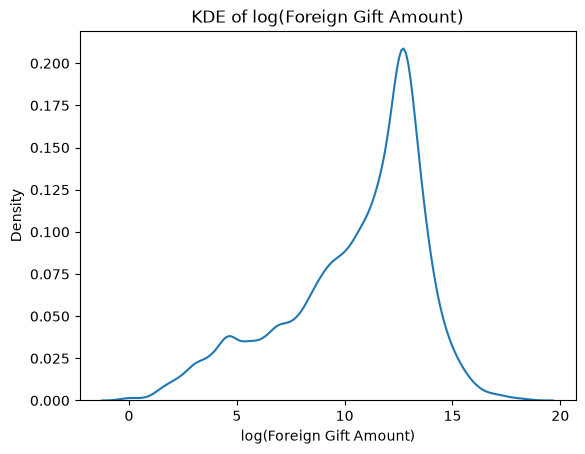

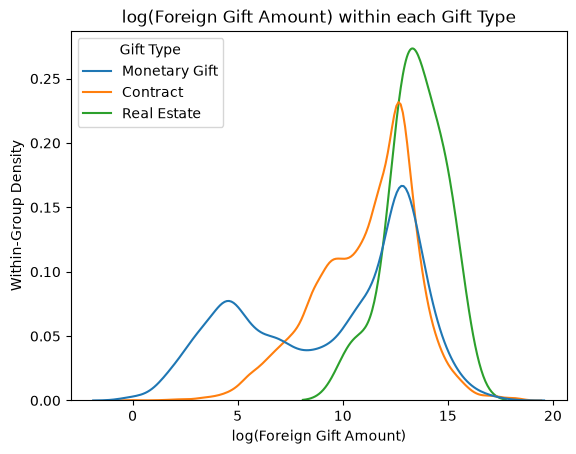

Country of Giftor
ENGLAND            3655
CHINA              2461
CANADA             2344
JAPAN              1896
SWITZERLAND        1676
SAUDI ARABIA       1610
FRANCE             1437
GERMANY            1394
HONG KONG          1080
SOUTH KOREA         811
QATAR               693
THE NETHERLANDS     512
KOREA               452
INDIA               434
TAIWAN              381
Name: Foreign Gift Amount, dtype: int64
Country of Giftor
QATAR                   2706240869
ENGLAND                 1464906771
CHINA                   1237952112
SAUDI ARABIA            1065205930
BERMUDA                  899593972
CANADA                   898160656
HONG KONG                887402529
JAPAN                    655954776
SWITZERLAND              619899445
INDIA                    539556490
GERMANY                  442475605
UNITED ARAB EMIRATES     431396357
FRANCE                   405839396
SINGAPORE                401157692
AUSTRALIA                248409202
Name: Foreign Gift Amount, dtype: int64

In [1]:
# Your Phase 2 solution to the problem goes here.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1.
gifts_df = pd.read_csv("./data/ForeignGifts_edu.csv")

# 2.
gifts_df["Foreign Gift Amount"].hist(bins = 20, grid = False)
plt.title("Foreign Gift Amount")
plt.xlabel("Foreign Gift Amount")
plt.ylabel("Count")
plt.show()

print(gifts_df["Foreign Gift Amount"].describe())

# Findings: The mean gift amount is about $588,233, but the median is only $94,615 (this means the mean is roughly 6x
# the median). This is a strong indicator to me that there is a right skew. The middle 50% of gifts fall between $5,700 
# and $376,142, while the max single gift is $99,999,999. A plain histogram on the raw scale is essentially useless because
# almost every bar will pile up near the left of the graph (nearish to zero) because that one outlier stretches the x-axis.

# 3.
sns.histplot(data=gifts_df, x = "Gift Type", stat = "proportion", discrete = True, shrink = 0.8)
plt.title("Proportion of Gifts by Gift Type")
plt.xlabel("Gift Type")
plt.ylabel("Proportion")
plt.show()

print(gifts_df["Gift Type"].value_counts(normalize = True))

# Findings: Contract 61.2%, Monetary Gift 38.8%, Real Estate 0.04%

# 4.
print(gifts_df["Foreign Gift Amount"].min())

gifts_df["log_gift_amount"] = np.log(gifts_df["Foreign Gift Amount"])

sns.kdeplot(x = gifts_df["log_gift_amount"])
plt.title("KDE of log(Foreign Gift Amount)")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Density")
plt.show()

sns.kdeplot(data = gifts_df, x = "log_gift_amount", hue = "Gift Type", common_norm = False)
plt.title("log(Foreign Gift Amount) within each Gift Type")
plt.xlabel("log(Foreign Gift Amount)")
plt.ylabel("Within-Group Density")
plt.show()

# Findings: The log-transformed KDE plot shows that gift type is closely related with gift size. Once the right skew is pulled
# in by the log transformation, the overall distribution looks roughly bell-shaped, unlike the skewed raw scale. Conditioning
# by type, Real Estate gifts sit furthest to the right, meaning they tend to be the largest gifts. Contract gifts cluster in a 
# harrower, higher peak, which could mean most of those Contracts fall within a fairly consistant, moderate dollar range.
# Monetary Gifts on the other hand show a much flatter, wider spread, reflecting that this category includes everything from very
# small donations to very large gifts rather than clustering around one typical size. Overall, I think that these patters suggest
# that while contracts are the most common gift type, monetary gifts vary the most in size, and real estate tends to involve the 
# largest amounts. 

# 5.
top15_count = gifts_df.groupby("Country of Giftor")["Foreign Gift Amount"].size().sort_values(ascending = False).head(15)
print(top15_count)

# Top 15 Countries (# gifts): ENGLAND, CHINA, CANADA, JAPAN, SWITZERLAND, SAUDI ARABIA, FRANCE, GERMANY, HONG KONG, SOUTH KOREA, QATAR, THE NETHERLANDS,
# KOREA, INDIA, TAIWAN

top15_amount = gifts_df.groupby("Country of Giftor")["Foreign Gift Amount"].sum().sort_values(ascending = False).head(15)
print(top15_amount)

# Top 15 Countries (amt given): QATAR, ENGLAND, CHINA, SAUDI ARABIA, BERMUDA, CANADA, HONG KONG, JAPAN, SWITZERLAND, INDIA, GERMANY, UNITED ARAB EMIRATES,
# FRANCE, SINGAPORE, AUSTRALIA

# 6.
top_giftors = gifts_df.groupby("Giftor Name")["Foreign Gift Amount"].sum().sort_values(ascending = False).head(15)
print(top_giftors)

# Top Giftor: Qatar Foundation, Qatar Foundation/Qatar National Res, Qatar Foundation for Education, Anonymous, Saudi Arabian Cultural Mission, HCL,
# Church of Jesus Christ of LDS, Emirates Institute for Advanced Sc, QIC, Anonymous #9, Qatar National Research Fund, Government of Saudi Arabia, Contracting Party,
# CMKL University, Royal Embassy of Saudi Arabia

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

Two of the changes AI suggested were helpful: switching .count() to .size() when grouping ensures rows with a missisng Foreign Gift amount don't get dropped without me noticing, so the counts by giftor/country are more accurate. Adding a check for zero or negative values before doing no.log() also was a helpful tweak since log of zero or a negative number gives you -inf/NaN, and that would've messed up my KDE plots in setp 4 without me realizing. The AI also suggested stuff that didn't seem super necessary aside from cosmetic changes. The "add a missing value chec" one was very similar to the issue I already fixed with .size(), so it felt redundant to add. It also suggested adding commas to dollar amounts and setting order for the Gift Type histogram bars, both of which didn't fix any of my findings and ultimately authors preference. It also interpreted step 6 differently than I did which was interesting, it recommended only print one top giftor because I printed a list of 15. I didn't modify my original answer because I don't think it mattered whether I printed 1 or 15, but it's kinda neat that AI can track tenses and notice when questions ask for one answer vs a list of answers.